# Phase 6 — Augmentation Ablation

The SimCLR paper's big finding was that the *augmentation* choice matters
way more than the architecture / loss. Specifically, color distortion is
doing most of the heavy lifting — without it, the network can solve the
contrastive task by cheating on local color statistics.

Test that directly. Four variants trained here, Phase 1 "full" pulled from
disk for the baseline.

| name       | crop | flip | color | gray | strength |
|------------|------|------|-------|------|----------|
| full (P1)  | ✓    | ✓    | ✓     | ✓    | 0.4      |
| no_color   | ✓    | ✓    |       | ✓    | —        |
| no_gray    | ✓    | ✓    | ✓     |      | 0.4      |
| crop_only  | ✓    | ✓    |       |      | —        |
| stronger   | ✓    | ✓    | ✓     | ✓    | 0.8      |


In [1]:
# --- Cell 1: Imports & Config ---
import json, os, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    get_device, get_cifar_resnet18, get_eval_transform, get_simclr_transform,
    ProjectionHead, SimCLRModel, nt_xent_loss, knn_monitor, SimCLRPairDataset,
)

SMOKE_TEST = False

# kwargs to get_simclr_transform for each variant
VARIANTS = {
    'no_color':  dict(use_color_jitter=False, use_grayscale=True,  color_jitter_strength=0.4),
    'no_gray':   dict(use_color_jitter=True,  use_grayscale=False, color_jitter_strength=0.4),
    'crop_only': dict(use_color_jitter=False, use_grayscale=False, color_jitter_strength=0.4),
    'stronger':  dict(use_color_jitter=True,  use_grayscale=True,  color_jitter_strength=0.8),
}
BASELINE_NAME = 'full'  # Phase 1

cfg = dict(
    batch_size    = 256,
    ssl_epochs    = 2  if SMOKE_TEST else 50,
    probe_epochs  = 3  if SMOKE_TEST else 50,
    lr            = 3e-4,
    probe_lr      = 1e-3,
    weight_decay  = 1e-6,
    temperature   = 0.5,
    seed          = 42,
    num_workers   = 0,
    data_root     = './data',
    knn_k         = 20,
    knn_interval  = 10,
    ckpt_dir      = 'models/ablation_augmentation' if not SMOKE_TEST else 'models/ablation_augmentation_smoke',
    results_path  = 'results/ablation_augmentation.json' if not SMOKE_TEST else 'results/ablation_augmentation_smoke.json',
    fig_path      = 'figures/ablation_augmentation_curves.png' if not SMOKE_TEST else 'figures/ablation_augmentation_smoke.png',
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])
os.makedirs(cfg['ckpt_dir'], exist_ok=True)
os.makedirs('results', exist_ok=True); os.makedirs('figures', exist_ok=True)

device = get_device()
print('Device:', device)
print('Variants:', list(VARIANTS.keys()), f' (baseline={BASELINE_NAME} reused)')


Device: privateuseone:0
Variants: ['no_color', 'no_gray', 'crop_only', 'stronger']  (baseline=full reused)


In [2]:
# --- Cell 2: Data (variant-specific SSL transform) ---
eval_transform = get_eval_transform(32)
train_eval_ds  = CIFAR10(cfg['data_root'], train=True,  download=True, transform=eval_transform)
test_ds        = CIFAR10(cfg['data_root'], train=False, download=True, transform=eval_transform)

memory_loader = DataLoader(train_eval_ds, batch_size=512, shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=False)
test_loader   = DataLoader(test_ds, batch_size=512, shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=False)
probe_train_loader = DataLoader(train_eval_ds, batch_size=cfg['batch_size'],
                                shuffle=True, num_workers=cfg['num_workers'],
                                pin_memory=False, drop_last=False)

def make_ssl_loader(aug_kwargs: dict):
    t = get_simclr_transform(32, **aug_kwargs)
    ds = SimCLRPairDataset(CIFAR10(cfg['data_root'], train=True, download=True, transform=None), transform=t)
    return DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True,
                      num_workers=cfg['num_workers'], pin_memory=False, drop_last=True)
print('data ready.')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
data ready.


In [3]:
# --- Cell 3: Train one SimCLR with a given augmentation (resumable) ---
def _ckpt_path(name: str) -> str:
    return os.path.join(cfg['ckpt_dir'], f'simclr_aug_{name}.pth')

def train_variant(name: str, aug_kwargs: dict) -> dict:
    ckpt_path = _ckpt_path(name)
    ssl_loader = make_ssl_loader(aug_kwargs)
    torch.manual_seed(cfg['seed'])
    model = SimCLRModel(get_cifar_resnet18(), hidden_dim=512, proj_dim=128).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    log = {'epoch': [], 'loss': [], 'knn_epoch': [], 'knn_acc': [], 'epoch_sec': []}
    start_epoch = 1

    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        model.load_state_dict(ck['model_state']); model.to(device)
        optimizer.load_state_dict(ck['optimizer_state'])
        log = ck['log']; start_epoch = ck['epoch'] + 1
        print(f'  [{name}] RESUMING from epoch {start_epoch}', flush=True)
    else:
        print(f'  [{name}] starting fresh', flush=True)

    for epoch in range(start_epoch, cfg['ssl_epochs']+1):
        model.train(); t0 = time.time(); loss_sum = n_batches = 0
        pbar = tqdm(ssl_loader, desc=f'{name} ep {epoch}/{cfg["ssl_epochs"]}', leave=False)
        for v1, v2, _ in pbar:
            v1 = v1.to(device); v2 = v2.to(device)
            x = torch.cat([v1, v2], dim=0)
            _, z = model(x); z = F.normalize(z, dim=1)
            loss = nt_xent_loss(z, temperature=cfg['temperature'])
            optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
            loss_sum += float(loss.detach().cpu()); n_batches += 1
        avg_loss = loss_sum/max(n_batches, 1); dt = time.time() - t0
        log['epoch'].append(epoch); log['loss'].append(avg_loss); log['epoch_sec'].append(dt)
        if epoch == 1 or epoch % cfg['knn_interval'] == 0 or epoch == cfg['ssl_epochs']:
            acc = knn_monitor(model.backbone, memory_loader, test_loader, device=device, k=cfg['knn_k'])
            log['knn_epoch'].append(epoch); log['knn_acc'].append(acc)
            print(f'    [{name}] ep {epoch:3d}  loss={avg_loss:.4f}  knn={acc*100:.2f}%  ({dt:.1f}s)', flush=True)
        tmp = ckpt_path + '.tmp'
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'log': log, 'aug_kwargs': aug_kwargs, 'name': name}, tmp)
        os.replace(tmp, ckpt_path)

    return {'ckpt_path': ckpt_path, 'log': log}

print('training routine ready.')


training routine ready.


In [4]:
# --- Cell 4: Train all variants ---
t_all = time.time()
runs = {}
for name, aug_kwargs in VARIANTS.items():
    print(f'>>> SSL run  {name}  ({aug_kwargs})', flush=True)
    t0 = time.time()
    r = train_variant(name, aug_kwargs)
    runs[name] = r
    print(f'    done in {(time.time()-t0)/60:.1f} min', flush=True)
print(f'\nall SSL runs done in {(time.time()-t_all)/60:.1f} min')


>>> SSL run  no_color  ({'use_color_jitter': False, 'use_grayscale': True, 'color_jitter_strength': 0.4})
Files already downloaded and verified
  [no_color] starting fresh


no_color ep 1/50:   0%|          | 0/195 [00:00<?, ?it/s]

c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


    [no_color] ep   1  loss=4.9089  knn=41.50%  (193.6s)


no_color ep 2/50:   0%|          | 0/195 [00:00<?, ?it/s]

...

stronger ep 47/50:   0%|          | 0/195 [00:00<?, ?it/s]

stronger ep 48/50:   0%|          | 0/195 [00:00<?, ?it/s]

stronger ep 49/50:   0%|          | 0/195 [00:00<?, ?it/s]

stronger ep 50/50:   0%|          | 0/195 [00:00<?, ?it/s]

    [stronger] ep  50  loss=4.6628  knn=76.63%  (210.1s)
    done in 171.1 min

all SSL runs done in 668.2 min


In [5]:
# --- Cell 5: Linear probe each variant ---
@torch.no_grad()
def _eval_clf(backbone, clf):
    backbone.eval(); clf.eval()
    corr = tot = 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = clf(backbone(x)).argmax(1)
        corr += (pred==y).sum().item(); tot += y.size(0)
    return corr/tot

def probe(backbone, epochs: int) -> dict:
    backbone.eval()
    for p in backbone.parameters(): p.requires_grad = False
    torch.manual_seed(cfg['seed'])
    clf = nn.Linear(512, 10).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=cfg['probe_lr'], weight_decay=cfg['weight_decay'])
    log = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': []}
    for epoch in range(1, epochs+1):
        clf.train(); ls = corr = tot = 0
        for x, y in probe_train_loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad(): h = backbone(x)
            logits = clf(h); loss = F.cross_entropy(logits, y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            ls += float(loss.detach().cpu())*y.size(0)
            corr += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
        log['epoch'].append(epoch); log['train_loss'].append(ls/tot)
        log['train_acc'].append(corr/tot); log['test_acc'].append(_eval_clf(backbone, clf))
    return {'final_test_acc': log['test_acc'][-1],
            'best_test_acc':  max(log['test_acc']),
            'curve': log}

baseline_probe_path = Path('results/simclr_baseline_linear_probe.json')
baseline_result = None
if baseline_probe_path.exists():
    d = json.loads(baseline_probe_path.read_text())
    baseline_result = {'final_test_acc': d.get('final_test_acc'),
                       'best_test_acc': d.get('best_test_acc'),
                       'curve': d.get('curve')}
    print(f'Phase 1 baseline ({BASELINE_NAME}): best={baseline_result["best_test_acc"]*100:.2f}%')

probe_results = {}
for name in VARIANTS:
    print(f'>>> probe  {name}', flush=True)
    ck = torch.load(_ckpt_path(name), map_location='cpu', weights_only=False)
    bb = get_cifar_resnet18().to(device)
    bb_state = {k[len('backbone.'):]: v for k, v in ck['model_state'].items() if k.startswith('backbone.')}
    bb.load_state_dict(bb_state)
    t0 = time.time()
    r = probe(bb, cfg['probe_epochs'])
    probe_results[name] = r
    print(f'    final={r["final_test_acc"]*100:.2f}%  best={r["best_test_acc"]*100:.2f}%  ({time.time()-t0:.1f}s)', flush=True)

final = {
    'variants': list(VARIANTS.keys()),
    'baseline': baseline_result,
    'ssl_epochs':   cfg['ssl_epochs'],
    'probe_epochs': cfg['probe_epochs'],
    'runs': {n: {'ssl_log': runs[n]['log'], 'probe': probe_results[n],
                 'aug_kwargs': VARIANTS[n]} for n in VARIANTS},
}
with open(cfg['results_path'], 'w') as f: json.dump(final, f, indent=2)
print('Saved', cfg['results_path'])


Phase 1 baseline (full): best=86.70%
>>> probe  no_color
    final=73.27%  best=73.27%  (996.0s)
>>> probe  no_gray
    final=70.48%  best=70.57%  (1070.7s)
>>> probe  crop_only
    final=57.07%  best=57.35%  (1070.2s)
>>> probe  stronger
    final=79.91%  best=79.91%  (1151.6s)
Saved results/ablation_augmentation.json


Augmentation ablation — CIFAR-10 linear probe
variant          final      best
----------------------------------------------------------
full (P1)       86.34%    86.70%
no_color        73.27%    73.27%
no_gray         70.48%    70.57%
crop_only       57.07%    57.35%
stronger        79.91%    79.91%


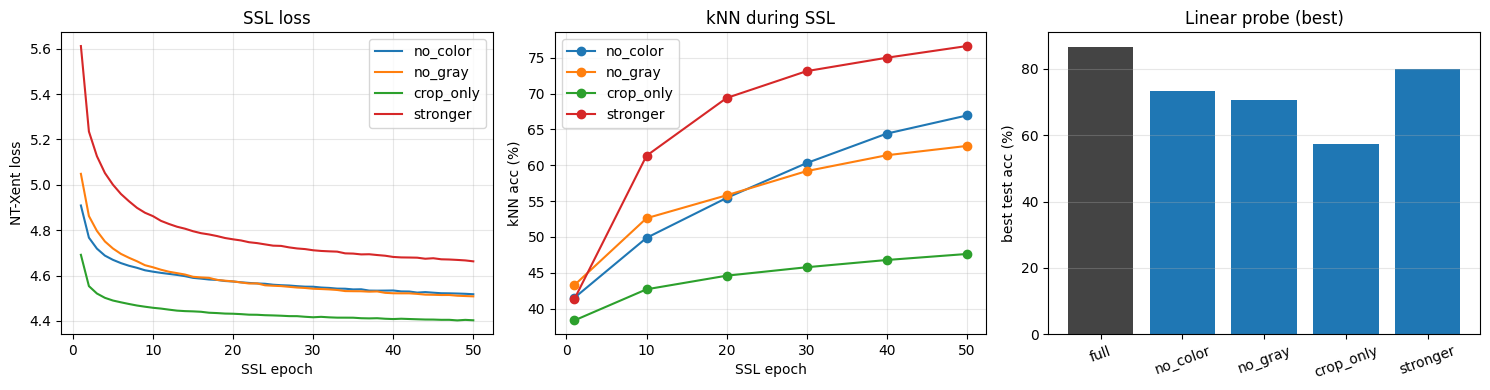

Saved figures/ablation_augmentation_curves.png


In [6]:
# --- Cell 6: Results table + plots ---
def _fmt(x): return f'{x*100:.2f}%' if x is not None else '   n/a '
print('Augmentation ablation — CIFAR-10 linear probe')
print('=' * 58)
print(f"{'variant':<12}  {'final':>8}  {'best':>8}")
print('-' * 58)
if baseline_result is not None:
    print(f"{'full (P1)':<12}  {_fmt(baseline_result['final_test_acc']):>8}  {_fmt(baseline_result['best_test_acc']):>8}")
for name in VARIANTS:
    r = probe_results[name]
    print(f'{name:<12}  {_fmt(r["final_test_acc"]):>8}  {_fmt(r["best_test_acc"]):>8}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in VARIANTS:
    log = runs[name]['log']
    axes[0].plot(log['epoch'], log['loss'], label=name)
axes[0].set_xlabel('SSL epoch'); axes[0].set_ylabel('NT-Xent loss')
axes[0].set_title('SSL loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

for name in VARIANTS:
    log = runs[name]['log']
    axes[1].plot(log['knn_epoch'], [a*100 for a in log['knn_acc']], marker='o', label=name)
axes[1].set_xlabel('SSL epoch'); axes[1].set_ylabel('kNN acc (%)')
axes[1].set_title('kNN during SSL'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Bar chart of best probe acc
names_order = ['full'] + list(VARIANTS.keys()) if baseline_result is not None else list(VARIANTS.keys())
vals = []
for n in names_order:
    if n == 'full' and baseline_result is not None:
        vals.append(baseline_result['best_test_acc']*100)
    else:
        vals.append(probe_results[n]['best_test_acc']*100)
axes[2].bar(names_order, vals, color=['#444']+['#1f77b4']*(len(names_order)-1))
axes[2].set_ylabel('best test acc (%)'); axes[2].set_title('Linear probe (best)')
axes[2].grid(axis='y', alpha=0.3)
for tick in axes[2].get_xticklabels(): tick.set_rotation(20)

fig.tight_layout(); fig.savefig(cfg['fig_path'], dpi=150); plt.show()
print('Saved', cfg['fig_path'])
